# 02 — Exploratory Data Analysis

Five charts for the LinkedIn article + answers to the core EDA questions:

1. How many inversions exist in the historical record?
2. What is the hit rate (inversions followed by recession within 24 months)?
3. Were there false positives?
4. What is the distribution of lead times?
5. Does 2s10s vs. 10Y–3M tell different stories?

**Prereq:** run `01_data_pull.ipynb` first.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.signal_utils import recession_bands, find_inversion_episodes
from src import viz

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.float_format', '{:.2f}'.format)

## Load data

In [2]:
df = pd.read_csv('../data/raw/merged_monthly.csv', index_col=0, parse_dates=True)
print(f'Loaded: {df.shape[0]} months, {df.index.min().date()} to {df.index.max().date()}')

rec_bands = recession_bands(df['USREC'].dropna())

Loaded: 870 months, 1954-01-31 to 2026-06-30


## Chart 1 — Classic 2s10s with recession shading

This is the money shot for the article.

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\01_2s10s_classic.png


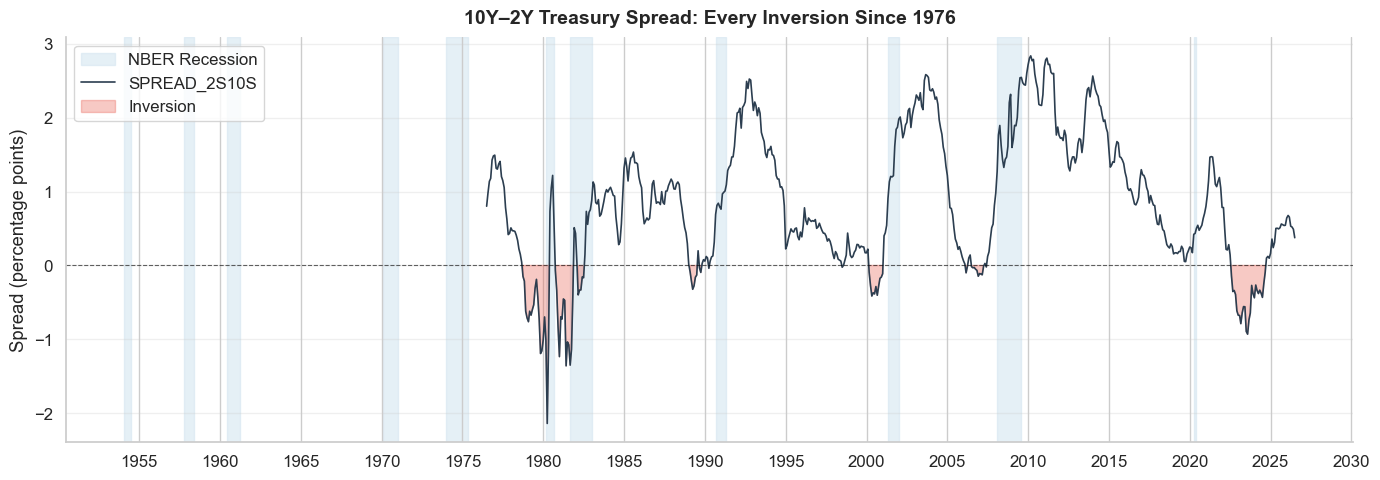

In [3]:
viz.plot_spread_history(
    df['SPREAD_2S10S'].dropna(),
    rec_bands,
    title='10Y–2Y Treasury Spread: Every Inversion Since 1976',
    save_path='01_2s10s_classic.png',
)
plt.show()

## Chart 2 — Both spreads overlaid: 2s10s vs. 10Y–3M

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\02_both_spreads.png


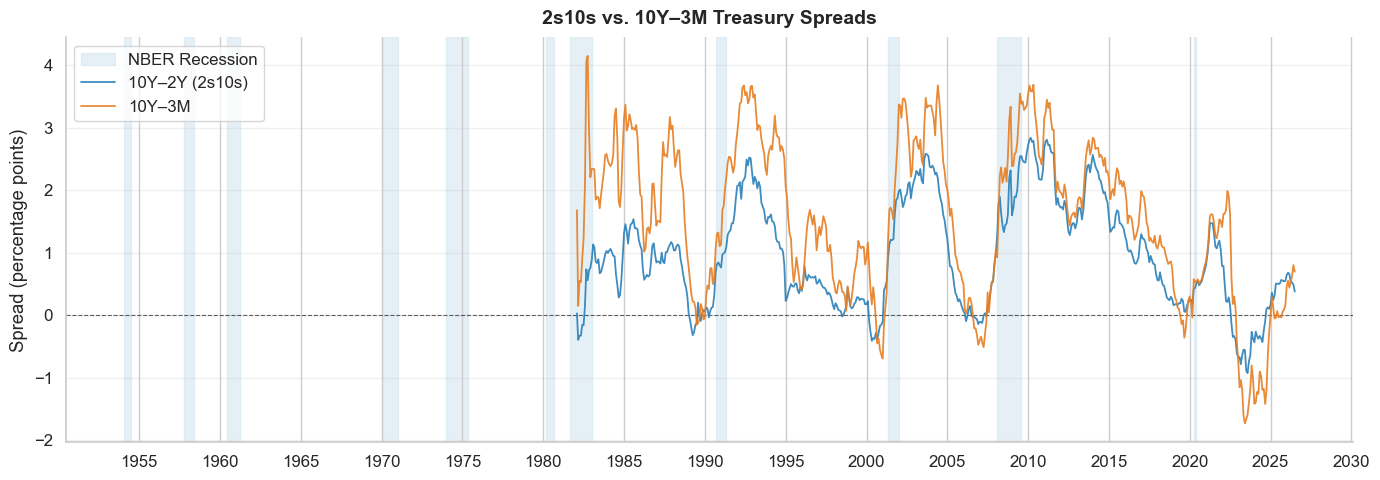

In [4]:
# Align on their overlapping period
both = df[['SPREAD_2S10S', 'SPREAD_10Y3M']].dropna()

viz.plot_both_spreads(
    both['SPREAD_2S10S'],
    both['SPREAD_10Y3M'],
    rec_bands,
    save_path='02_both_spreads.png',
)
plt.show()

## Chart 3 — Component yields: what's actually moving?

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\03_component_yields.png


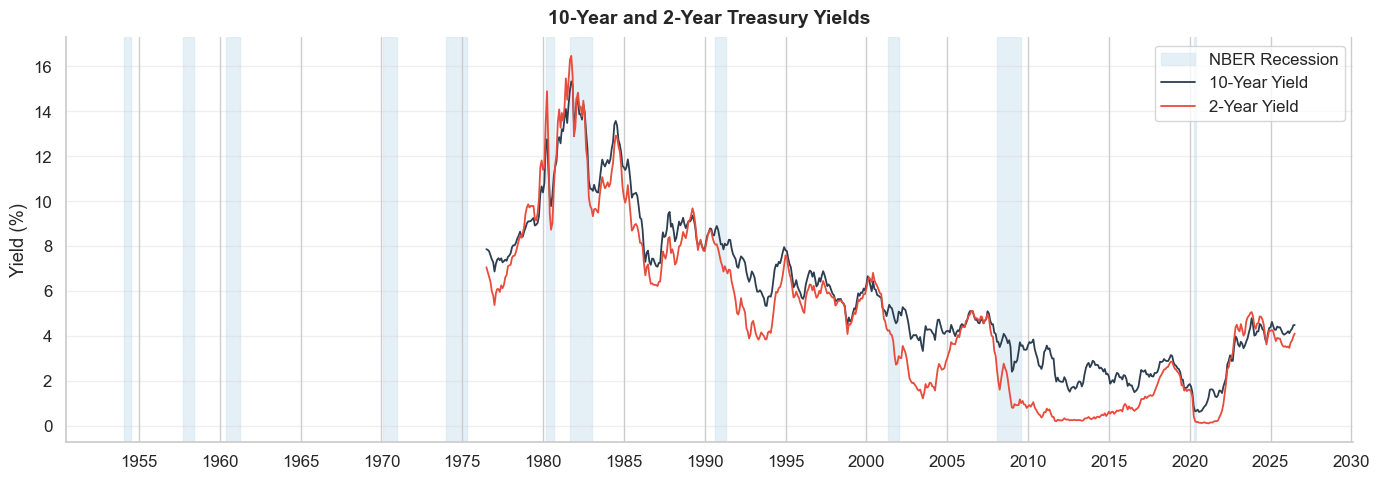

In [5]:
yields = df[['DGS10', 'DGS2']].dropna()

viz.plot_component_yields(
    yields['DGS10'],
    yields['DGS2'],
    rec_bands,
    save_path='03_component_yields.png',
)
plt.show()

## Chart 4 — Fed Funds Rate vs. yield curve

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\04_fedfunds_vs_spread.png


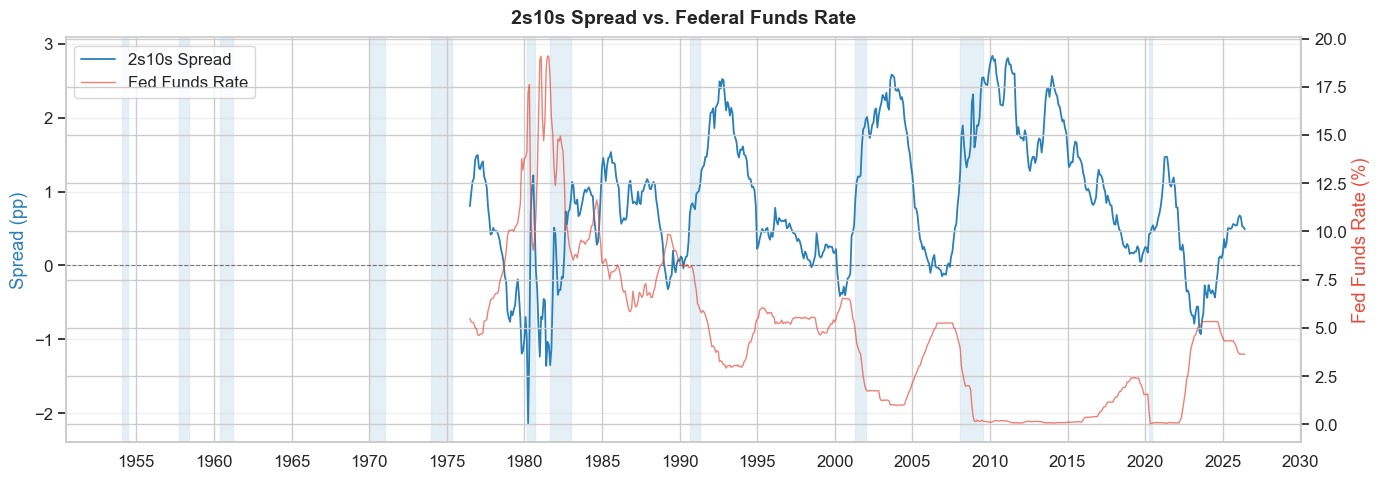

In [6]:
ff_align = df[['SPREAD_2S10S', 'FEDFUNDS']].dropna()

viz.plot_fedfunds_vs_spread(
    ff_align['SPREAD_2S10S'],
    ff_align['FEDFUNDS'],
    rec_bands,
    save_path='04_fedfunds_vs_spread.png',
)
plt.show()

## Chart 5 — 2022–2024 episode in isolation

Spread + unemployment + CPI on one chart.

C:\Users\frase\AppData\Local\Temp\ipykernel_24908\2022923819.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['CPI_YOY'] = df['CPIAUCSL'].pct_change(12) * 100


  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\05_2022_episode_overview.png


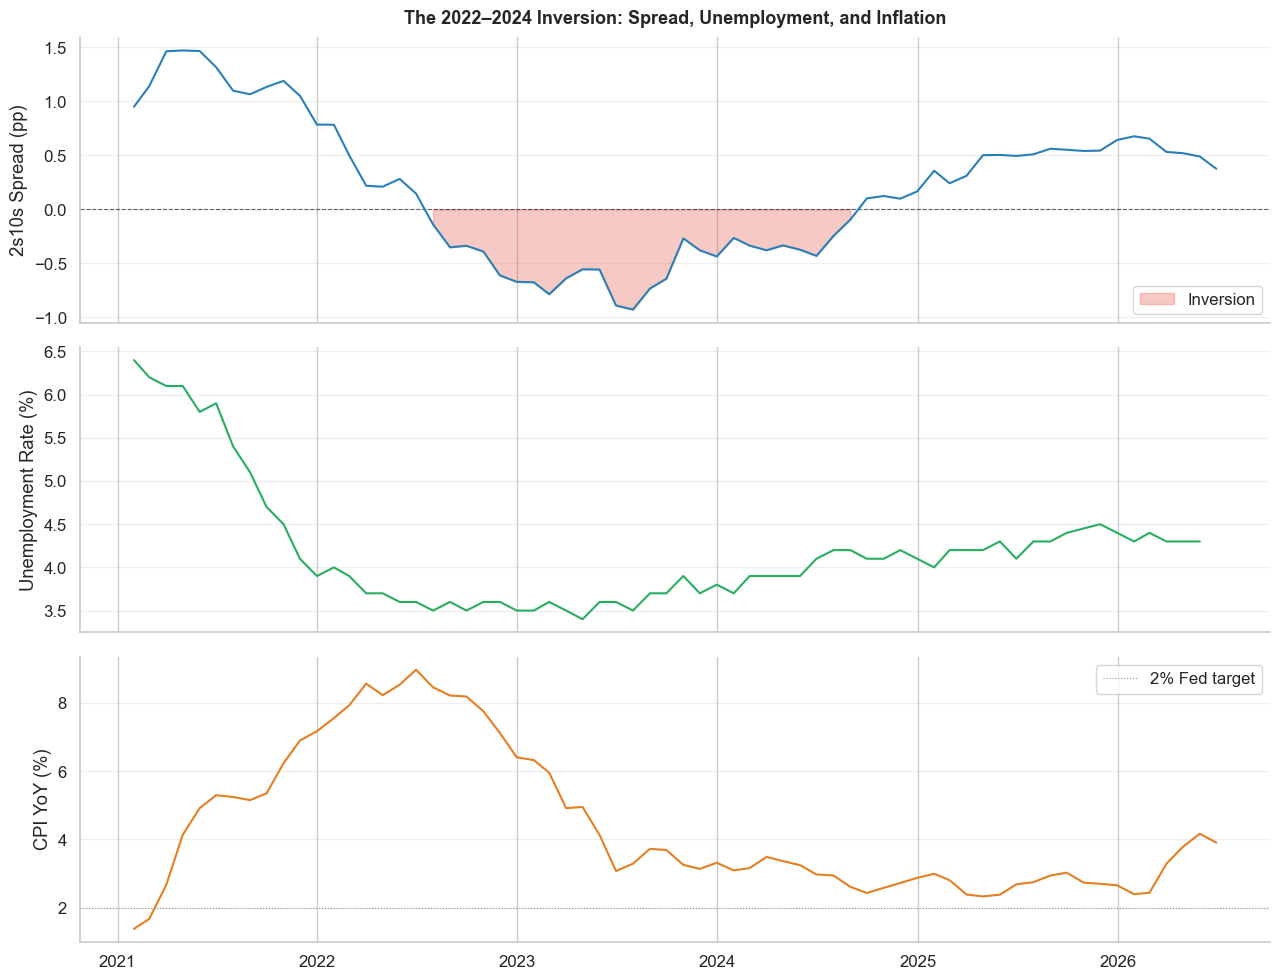

In [7]:
# Compute CPI YoY % change
df['CPI_YOY'] = df['CPIAUCSL'].pct_change(12) * 100

viz.plot_2022_episode(
    df['SPREAD_2S10S'].dropna(),
    df['UNRATE'].dropna(),
    df['CPI_YOY'].dropna(),
    rec_bands,
    start='2021-01-01',
    save_path='05_2022_episode_overview.png',
)
plt.show()

## EDA Q&A

### How many inversions in the historical record?

In [8]:
episodes_2s10s = find_inversion_episodes(
    df['SPREAD_2S10S'].dropna(),
    min_duration_months=3,
    min_separation_months=12,
)

episodes_10y3m = find_inversion_episodes(
    df['SPREAD_10Y3M'].dropna(),
    min_duration_months=3,
    min_separation_months=12,
)

print('=== 2s10s Episodes ===')
print(episodes_2s10s[['episode_id','start','end','duration_months','max_depth','ongoing']].to_string(index=False))
print(f'\nTotal: {len(episodes_2s10s)}')

print('\n=== 10Y–3M Episodes ===')
print(episodes_10y3m[['episode_id','start','end','duration_months','max_depth','ongoing']].to_string(index=False))
print(f'\nTotal: {len(episodes_10y3m)}')

=== 2s10s Episodes ===
 episode_id      start        end  duration_months  max_depth  ongoing
          1 1978-09-30 1982-06-30               46      -2.14    False
          2 1989-01-31 1990-03-31               15      -0.32    False
          3 2000-02-29 2000-12-31               11      -0.41    False
          4 2006-02-28 2007-05-31               16      -0.15    False
          5 2022-07-31 2024-08-31               26      -0.93    False

Total: 5

=== 10Y–3M Episodes ===
 episode_id      start        end  duration_months  max_depth  ongoing
          1 1989-06-30 1989-12-31                7      -0.16    False
          2 2000-07-31 2001-01-31                7      -0.70    False
          3 2006-08-31 2007-05-31               10      -0.52    False
          4 2019-05-31 2020-02-29               10      -0.36    False
          5 2022-11-30 2026-06-30               44      -1.73     True

Total: 5


### Comparison: Do 2s10s and 10Y–3M invert together?

The 10Y–3M spread is the NY Fed's preferred measure. The two series agree most of the time but have some divergence — worth flagging in the article.

In [9]:
both_flags = pd.DataFrame({
    '2s10s_inverted':  (df['SPREAD_2S10S'] < 0).astype(int),
    '10y3m_inverted':  (df['SPREAD_10Y3M'] < 0).astype(int),
}).dropna()

agree = (both_flags['2s10s_inverted'] == both_flags['10y3m_inverted']).mean()
print(f'Agreement rate: {agree:.1%}')

# Months where they disagree
disagreement = both_flags[both_flags['2s10s_inverted'] != both_flags['10y3m_inverted']]
print(f'Months of disagreement: {len(disagreement)}')
print('\nDisagreement periods (sample):')
print(disagreement.head(20))

Agreement rate: 90.9%
Months of disagreement: 79

Disagreement periods (sample):
            2s10s_inverted  10y3m_inverted
date                                      
1978-09-30               1               0
1978-10-31               1               0
1978-11-30               1               0
1978-12-31               1               0
1979-01-31               1               0
1979-02-28               1               0
1979-03-31               1               0
1979-04-30               1               0
1979-05-31               1               0
1979-06-30               1               0
1979-07-31               1               0
1979-08-31               1               0
1979-09-30               1               0
1979-10-31               1               0
1979-11-30               1               0
1979-12-31               1               0
1980-01-31               1               0
1980-02-29               1               0
1980-03-31               1               0
1980-04-30      

### Summary statistics of the 2s10s spread

In [10]:
spread = df['SPREAD_2S10S'].dropna()
print(spread.describe())
print(f'\nMonths inverted (< 0): {(spread < 0).sum()} ({(spread < 0).mean():.1%} of observations)')
print(f'Deepest inversion: {spread.min():.2f} pp on {spread.idxmin().date()}')

count   601.00
mean      0.85
std       0.91
min      -2.14
25%       0.19
50%       0.78
75%       1.47
max       2.83
Name: SPREAD_2S10S, dtype: float64

Months inverted (< 0): 99 (16.5% of observations)
Deepest inversion: -2.14 pp on 1980-03-31
